In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, StratifiedKFold)
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score,
                              roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize
import joblib

plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')

SEED       = 42
LABEL_MAP  = {'RENDAH': 0, 'SEDANG': 1, 'TINGGI': 2}
LABEL_INV  = {v: k for k, v in LABEL_MAP.items()}
COLORS     = {'RENDAH': '#70AD47', 'SEDANG': '#FFC000', 'TINGGI': '#FF4444'}
np.random.seed(SEED)
print("✅ Semua library berhasil diimport")

✅ Semua library berhasil diimport


In [2]:
df = pd.read_csv('ygini.csv')
print(f"Shape   : {df.shape}")
print(f"Kolom   : {list(df.columns)}")
print()
df.head()

Shape   : (1000, 23)
Kolom   : ['id', 'q1_raw', 'q2_raw', 'q3_raw', 'q4_raw', 'q5_raw', 'q6_raw', 'q7_raw', 'q8_raw', 'q9_raw', 'q10_raw', 'q1_adj', 'q2_adj', 'q3_adj', 'q4_adj', 'q5_adj', 'q6_adj', 'q7_adj', 'q8_adj', 'q9_adj', 'q10_adj', 'skor_total', 'label']



,id,q1_raw,q2_raw,q3_raw,q4_raw,q5_raw,q6_raw,q7_raw,q8_raw,q9_raw,...,q3_adj,q4_adj,q5_adj,q6_adj,q7_adj,q8_adj,q9_adj,q10_adj,skor_total,label
0,1,4,3,2,1,2,4,3,0,3,...,2,1,2,0,1,4,1,2,20,SEDANG
1,2,4,0,2,4,4,0,1,1,1,...,2,4,4,4,3,3,3,2,29,TINGGI
2,3,1,4,4,1,4,0,0,2,3,...,4,1,4,4,4,2,1,2,27,TINGGI
3,4,0,1,4,1,0,1,1,1,3,...,4,1,0,3,3,3,1,1,17,SEDANG
4,5,2,1,0,4,2,1,1,4,4,...,0,4,2,3,3,0,0,4,19,SEDANG


In [3]:
print("=== STATISTIK DESKRIPTIF (kolom adj) ===")
adj_cols = [f'q{i+1}_adj' for i in range(10)]
df[adj_cols + ['skor_total']].describe().round(2)

=== STATISTIK DESKRIPTIF (kolom adj) ===


,q1_adj,q2_adj,q3_adj,q4_adj,q5_adj,q6_adj,q7_adj,q8_adj,q9_adj,q10_adj,skor_total
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,2.16,2.04,2.13,2.06,2.14,2.09,2.06,2.06,2.11,2.07,20.92
std,1.46,1.42,1.47,1.43,1.43,1.47,1.47,1.43,1.45,1.44,6.37
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,8.00
25%,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,15.00
50%,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,21.00
75%,4.00,3.00,4.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,27.00
max,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,35.00


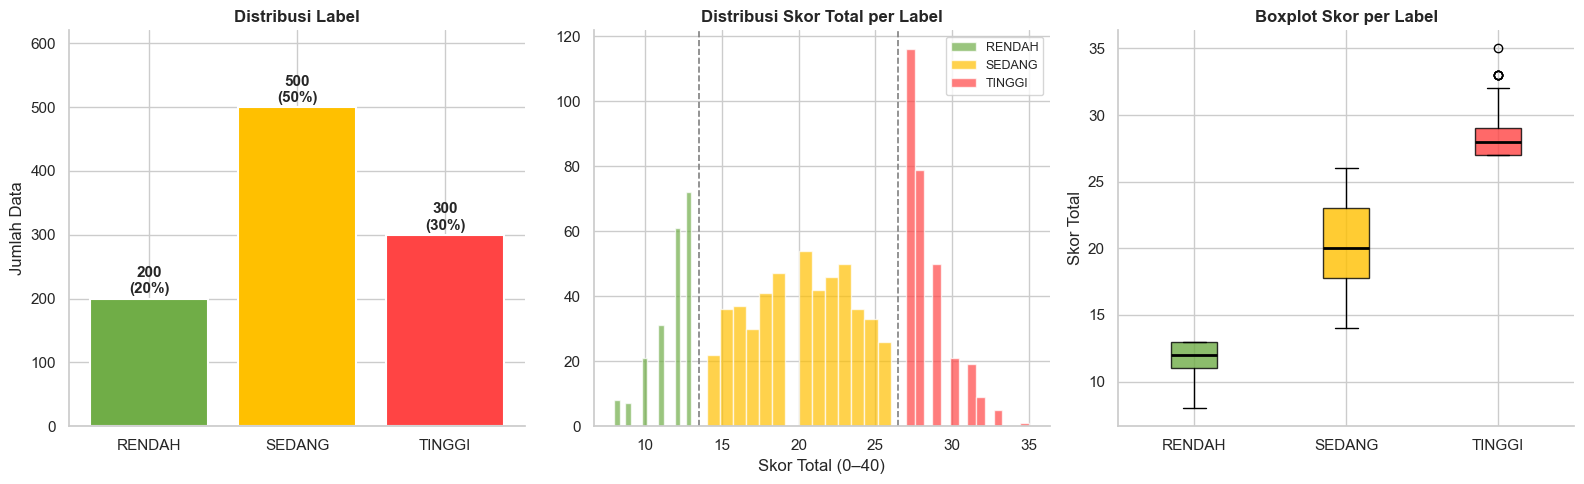

In [4]:
# ── Distribusi label & skor ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Bar distribusi label
label_counts = df['label'].value_counts().reindex(['RENDAH','SEDANG','TINGGI'])
bars = axes[0].bar(label_counts.index, label_counts.values,
                   color=[COLORS[l] for l in label_counts.index],
                   edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 f'{val}\n({val/len(df)*100:.0f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Distribusi Label', fontweight='bold')
axes[0].set_ylabel('Jumlah Data')
axes[0].set_ylim(0, 620)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# 2. Histogram skor
for lbl in ['RENDAH','SEDANG','TINGGI']:
    axes[1].hist(df[df['label']==lbl]['skor_total'], bins=14,
                 alpha=0.7, label=lbl, color=COLORS[lbl], edgecolor='white')
axes[1].axvline(13.5, color='gray', linestyle='--', linewidth=1.2)
axes[1].axvline(26.5, color='gray', linestyle='--', linewidth=1.2)
axes[1].set_title('Distribusi Skor Total per Label', fontweight='bold')
axes[1].set_xlabel('Skor Total (0–40)')
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# 3. Boxplot skor per label
data_box = [df[df['label']==l]['skor_total'].values for l in ['RENDAH','SEDANG','TINGGI']]
bp = axes[2].boxplot(data_box, patch_artist=True,
                     labels=['RENDAH','SEDANG','TINGGI'],
                     medianprops=dict(color='black', linewidth=2))
for patch, lbl in zip(bp['boxes'], ['RENDAH','SEDANG','TINGGI']):
    patch.set_facecolor(COLORS[lbl]); patch.set_alpha(0.8)
axes[2].set_title('Boxplot Skor per Label', fontweight='bold')
axes[2].set_ylabel('Skor Total')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('eda_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()

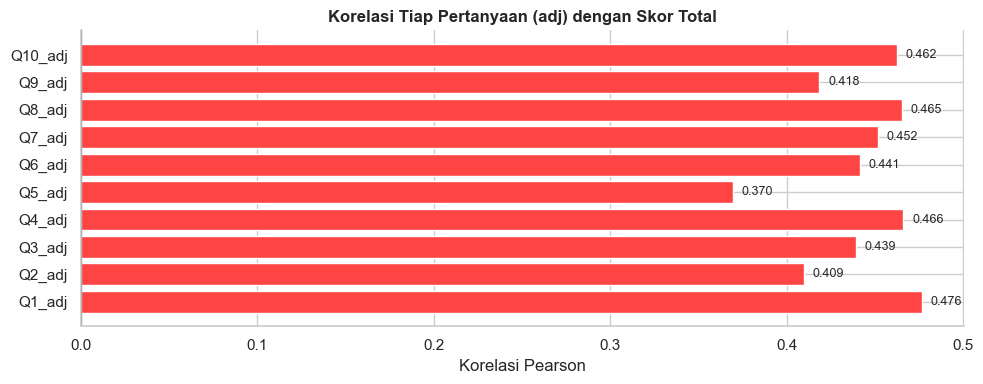

Semua q_adj berkorelasi positif → arah sudah benar setelah reversal ✅


In [5]:
# ── Heatmap korelasi q_adj vs skor_total ─────────────────────────────────
adj_cols = [f'q{i+1}_adj' for i in range(10)]
corr_vals = df[adj_cols + ['skor_total']].corr()['skor_total'][:-1]

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['#FF4444' if v > 0 else '#4472C4' for v in corr_vals]
bars = ax.barh([f'Q{i+1}_adj' for i in range(10)], corr_vals.values,
               color=bar_colors, edgecolor='white')
for bar, val in zip(bars, corr_vals.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_title('Korelasi Tiap Pertanyaan (adj) dengan Skor Total', fontweight='bold')
ax.set_xlabel('Korelasi Pearson')
ax.axvline(0, color='black', linewidth=0.8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('eda_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Semua q_adj berkorelasi positif → arah sudah benar setelah reversal ✅")

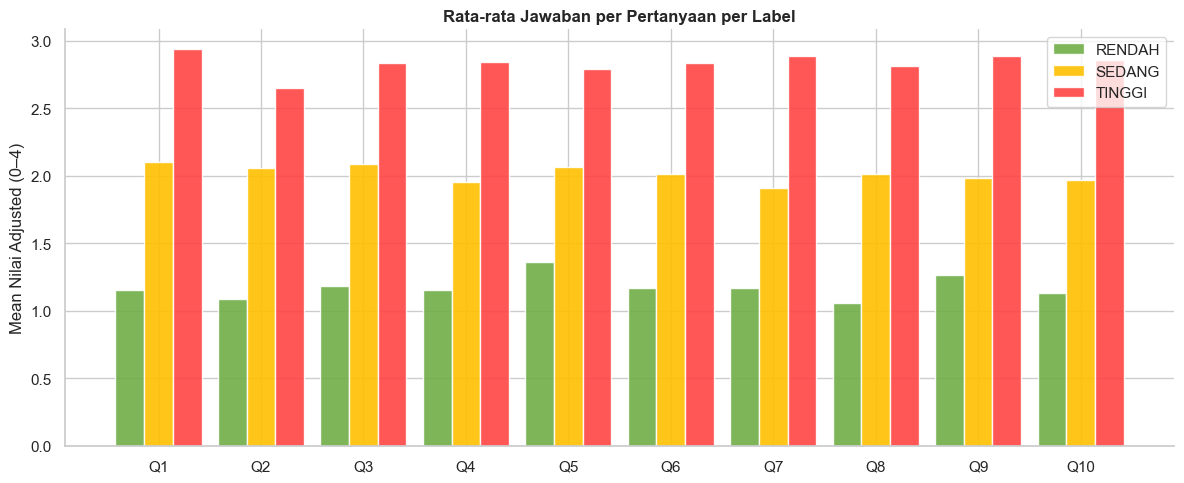

In [6]:
# ── Mean jawaban per pertanyaan per label ────────────────────────────────
adj_cols = [f'q{i+1}_adj' for i in range(10)]
mean_by_label = df.groupby('label')[adj_cols].mean().reindex(['RENDAH','SEDANG','TINGGI'])

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(10)
width = 0.28
for i, (lbl, color) in enumerate(COLORS.items()):
    ax.bar(x + i*width, mean_by_label.loc[lbl], width,
           label=lbl, color=color, edgecolor='white', alpha=0.9)
ax.set_xticks(x + width)
ax.set_xticklabels([f'Q{i+1}' for i in range(10)])
ax.set_title('Rata-rata Jawaban per Pertanyaan per Label', fontweight='bold')
ax.set_ylabel('Mean Nilai Adjusted (0–4)')
ax.legend()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('eda_mean_jawaban.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Fitur: HANYA 10 jawaban adjusted — tanpa skor_total
FEATURE_COLS = [f'q{i+1}_adj' for i in range(10)]
TARGET_COL   = 'label'

X = df[FEATURE_COLS].values
y = df[TARGET_COL].map(LABEL_MAP).values

print(f"Shape X (fitur) : {X.shape}  → {len(FEATURE_COLS)} fitur")
print(f"Shape y (target): {y.shape}")
print()
print("Fitur yang digunakan:")
for i, col in enumerate(FEATURE_COLS, 1):
    rev = '← reversed' if i >= 6 else ''
    print(f"  {i:2d}. {col}  {rev}")
print()
print("Distribusi kelas:")
for lbl, enc in LABEL_MAP.items():
    print(f"  {lbl} ({enc}): {(y==enc).sum()} data ({(y==enc).sum()/len(y)*100:.0f}%)")

Shape X (fitur) : (1000, 10)  → 10 fitur
Shape y (target): (1000,)

Fitur yang digunakan:
   1. q1_adj  
   2. q2_adj  
   3. q3_adj  
   4. q4_adj  
   5. q5_adj  
   6. q6_adj  ← reversed
   7. q7_adj  ← reversed
   8. q8_adj  ← reversed
   9. q9_adj  ← reversed
  10. q10_adj  ← reversed

Distribusi kelas:
  RENDAH (0): 200 data (20%)
  SEDANG (1): 500 data (50%)
  TINGGI (2): 300 data (30%)


In [8]:
# Train-Test Split — stratified agar distribusi terjaga
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y        # penting: jaga proporsi kelas
)

print(f"Train : {X_train.shape[0]} data (80%)")
print(f"Test  : {X_test.shape[0]} data (20%)")
print()
print("Distribusi train:")
for enc, lbl in LABEL_INV.items():
    n = (y_train==enc).sum()
    print(f"  {lbl}: {n} ({n/len(y_train)*100:.0f}%)")
print()
print("Distribusi test:")
for enc, lbl in LABEL_INV.items():
    n = (y_test==enc).sum()
    print(f"  {lbl}: {n} ({n/len(y_test)*100:.0f}%)")

Train : 800 data (80%)
Test  : 200 data (20%)

Distribusi train:
  RENDAH: 160 (20%)
  SEDANG: 400 (50%)
  TINGGI: 240 (30%)

Distribusi test:
  RENDAH: 40 (20%)
  SEDANG: 100 (50%)
  TINGGI: 60 (30%)


In [9]:
rf_base = RandomForestClassifier(
    n_estimators  = 100,
    random_state  = SEED,
    class_weight  = 'balanced',   # penanganan imbalance
    n_jobs        = -1
)
rf_base.fit(X_train, y_train)
print("✅ Model Random Forest baseline selesai ditraining")
print(f"   Jumlah pohon   : {rf_base.n_estimators}")
print(f"   Jumlah fitur   : {rf_base.n_features_in_}")
print(f"   Class weight   : {rf_base.class_weight}")

✅ Model Random Forest baseline selesai ditraining
   Jumlah pohon   : 100
   Jumlah fitur   : 10
   Class weight   : balanced


In [10]:
# Cross Validation pada data training
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_acc = cross_val_score(rf_base, X_train, y_train, cv=cv, scoring='accuracy')
cv_f1  = cross_val_score(rf_base, X_train, y_train, cv=cv, scoring='f1_macro')

print("Cross Validation (5-Fold) pada Training Set:")
print(f"{'Fold':<8} {'Accuracy':>10} {'F1 Macro':>10}")
print('-' * 30)
for i, (a, f) in enumerate(zip(cv_acc, cv_f1), 1):
    print(f"Fold {i:<3}  {a:>10.4f} {f:>10.4f}")
print('-' * 30)
print(f"{'Mean':<8} {cv_acc.mean():>10.4f} {cv_f1.mean():>10.4f}")
print(f"{'Std':<8} {cv_acc.std():>10.4f} {cv_f1.std():>10.4f}")

Cross Validation (5-Fold) pada Training Set:
Fold       Accuracy   F1 Macro
------------------------------
Fold 1        0.8562     0.8495
Fold 2        0.8750     0.8662
Fold 3        0.8313     0.8262
Fold 4        0.8375     0.8224
Fold 5        0.8063     0.7939
------------------------------
Mean         0.8412     0.8316
Std          0.0233     0.0247


In [11]:
y_pred_base  = rf_base.predict(X_test)
y_proba_base = rf_base.predict_proba(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
f1_base  = f1_score(y_test, y_pred_base, average='macro')

print("=" * 48)
print(f"  EVALUASI BASELINE")
print(f"  Accuracy  : {acc_base:.4f}  ({acc_base*100:.2f}%)")
print(f"  F1 Macro  : {f1_base:.4f}")
print("=" * 48)
print()
print(classification_report(
    y_test, y_pred_base,
    target_names=['RENDAH','SEDANG','TINGGI']
))

  EVALUASI BASELINE
  Accuracy  : 0.8700  (87.00%)
  F1 Macro  : 0.8557

              precision    recall  f1-score   support

      RENDAH       0.93      0.68      0.78        40
      SEDANG       0.82      0.94      0.88       100
      TINGGI       0.93      0.88      0.91        60

    accuracy                           0.87       200
   macro avg       0.90      0.83      0.86       200
weighted avg       0.88      0.87      0.87       200



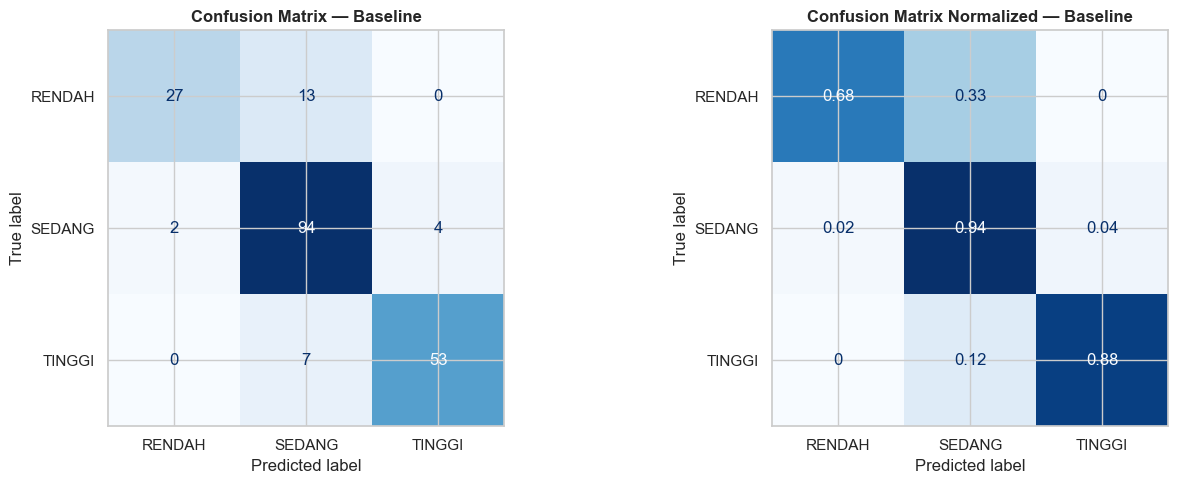

In [12]:
# Confusion Matrix baseline
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_base)
ConfusionMatrixDisplay(cm, display_labels=['RENDAH','SEDANG','TINGGI']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Baseline', fontweight='bold')

cm_n = confusion_matrix(y_test, y_pred_base, normalize='true')
ConfusionMatrixDisplay(cm_n, display_labels=['RENDAH','SEDANG','TINGGI']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix Normalized — Baseline', fontweight='bold')

plt.tight_layout()
plt.savefig('eval_cm_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

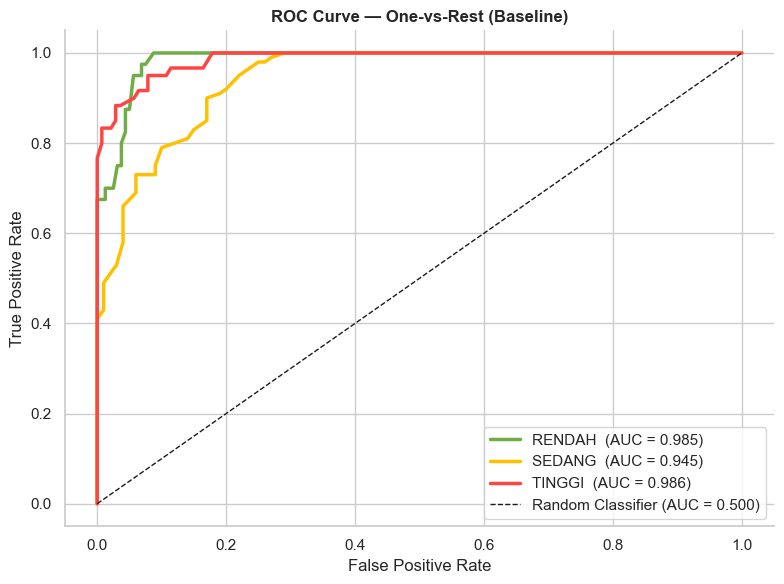

In [13]:
# ROC Curve baseline
y_test_bin  = label_binarize(y_test, classes=[0, 1, 2])
class_names = ['RENDAH', 'SEDANG', 'TINGGI']
roc_colors  = ['#70AD47', '#FFC000', '#FF4444']

fig, ax = plt.subplots(figsize=(8, 6))
for i, (name, color) in enumerate(zip(class_names, roc_colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_base[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f'{name}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — One-vs-Rest (Baseline)', fontweight='bold')
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('eval_roc_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
param_grid = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [None, 10, 20],
    'min_samples_split' : [2, 5],
    'min_samples_leaf'  : [1, 2],
}

grid_search = GridSearchCV(
    RandomForestClassifier(
        random_state  = SEED,
        class_weight  = 'balanced',
        n_jobs        = -1
    ),
    param_grid,
    cv       = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring  = 'f1_macro',
    n_jobs   = -1,
    verbose  = 1
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Tuning selesai")
print(f"   Best params : {grid_search.best_params_}")
print(f"   Best F1 CV  : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Tuning selesai
   Best params : {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
   Best F1 CV  : 0.8661


In [15]:
# Top 5 kombinasi terbaik dari GridSearch
cv_results = pd.DataFrame(grid_search.cv_results_)
top5 = (cv_results
        .sort_values('mean_test_score', ascending=False)
        .head(5)[['params','mean_test_score','std_test_score']])

print("Top 5 Kombinasi Parameter:")
print(f"{'Rank':<5} {'F1 Mean':>9} {'F1 Std':>9}  Params")
print('-' * 70)
for rank, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"  {rank:<3}  {row['mean_test_score']:>9.4f} {row['std_test_score']:>9.4f}  {row['params']}")

Top 5 Kombinasi Parameter:
Rank    F1 Mean    F1 Std  Params
----------------------------------------------------------------------
  1       0.8661    0.0250  {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
  2       0.8661    0.0250  {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
  3       0.8653    0.0313  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
  4       0.8653    0.0313  {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
  5       0.8645    0.0210  {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [16]:
rf_best       = grid_search.best_estimator_
y_pred_best   = rf_best.predict(X_test)
y_proba_best  = rf_best.predict_proba(X_test)

acc_best = accuracy_score(y_test, y_pred_best)
f1_best  = f1_score(y_test, y_pred_best, average='macro')

print("=" * 48)
print(f"  MODEL TERBAIK (setelah tuning)")
print(f"  Accuracy  : {acc_best:.4f}  ({acc_best*100:.2f}%)")
print(f"  F1 Macro  : {f1_best:.4f}")
print("=" * 48)
print()
print(classification_report(
    y_test, y_pred_best,
    target_names=['RENDAH','SEDANG','TINGGI']
))

  MODEL TERBAIK (setelah tuning)
  Accuracy  : 0.8600  (86.00%)
  F1 Macro  : 0.8586

              precision    recall  f1-score   support

      RENDAH       0.87      0.82      0.85        40
      SEDANG       0.87      0.85      0.86       100
      TINGGI       0.84      0.90      0.87        60

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200



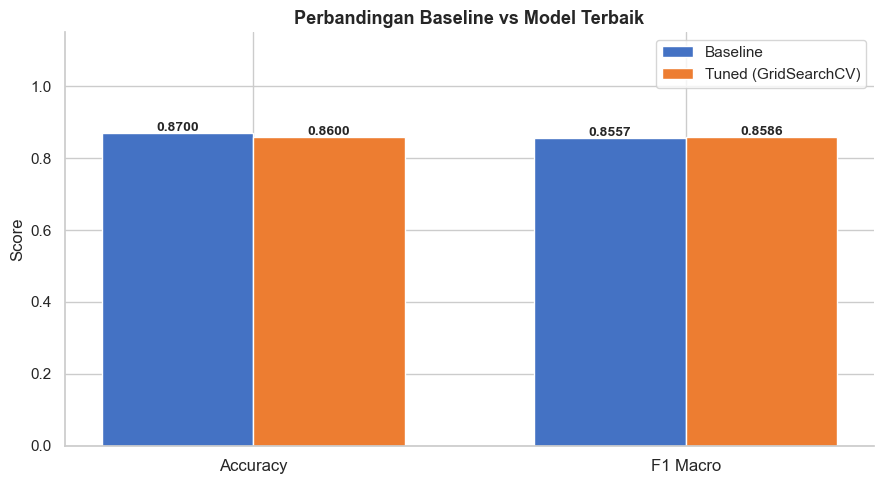

In [17]:
# Perbandingan Baseline vs Tuned
fig, ax = plt.subplots(figsize=(9, 5))

metrics  = ['Accuracy', 'F1 Macro']
baseline = [acc_base, f1_base]
tuned    = [acc_best, f1_best]
x        = np.arange(len(metrics))
width    = 0.35

b1 = ax.bar(x - width/2, baseline, width, label='Baseline',
            color='#4472C4', edgecolor='white')
b2 = ax.bar(x + width/2, tuned,    width, label='Tuned (GridSearchCV)',
            color='#ED7D31', edgecolor='white')

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', fontsize=10, fontweight='bold')
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_title('Perbandingan Baseline vs Model Terbaik', fontweight='bold', fontsize=13)
ax.set_ylabel('Score')
ax.legend()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('eval_compare.png', dpi=150, bbox_inches='tight')
plt.show()

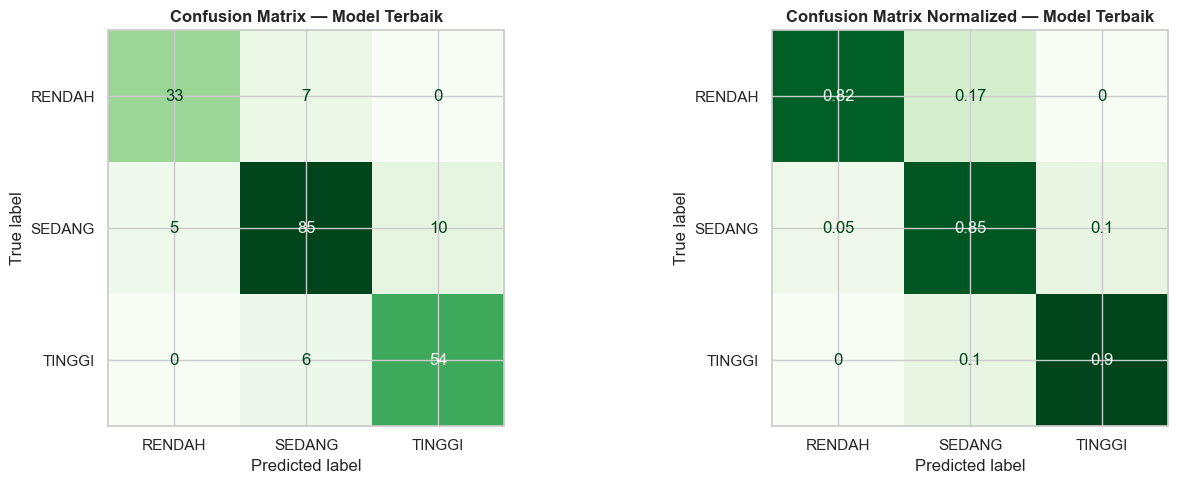

In [18]:
# Confusion Matrix model terbaik
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_b = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm_b, display_labels=['RENDAH','SEDANG','TINGGI']).plot(
    ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix — Model Terbaik', fontweight='bold')

cm_bn = confusion_matrix(y_test, y_pred_best, normalize='true')
ConfusionMatrixDisplay(cm_bn, display_labels=['RENDAH','SEDANG','TINGGI']).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Confusion Matrix Normalized — Model Terbaik', fontweight='bold')

plt.tight_layout()
plt.savefig('eval_cm_best.png', dpi=150, bbox_inches='tight')
plt.show()

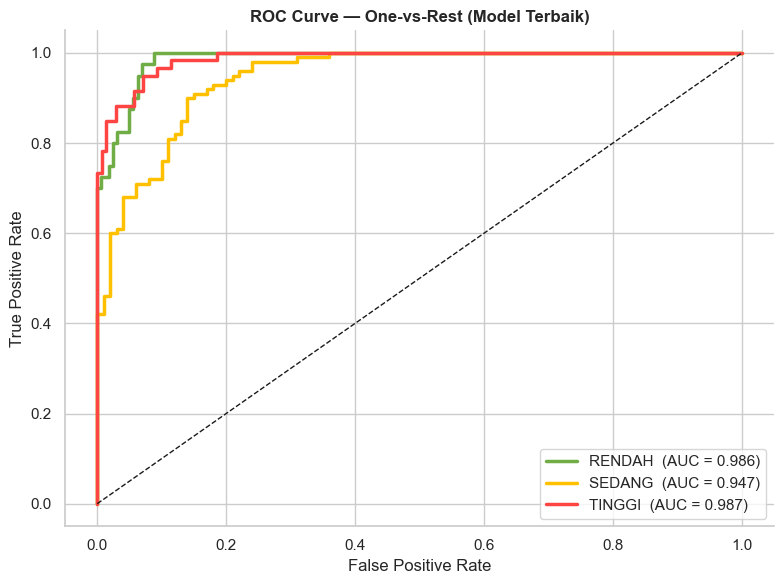

In [19]:
# ROC Curve model terbaik
fig, ax = plt.subplots(figsize=(8, 6))
for i, (name, color) in enumerate(zip(class_names, roc_colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_best[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f'{name}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — One-vs-Rest (Model Terbaik)', fontweight='bold')
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('eval_roc_best.png', dpi=150, bbox_inches='tight')
plt.show()

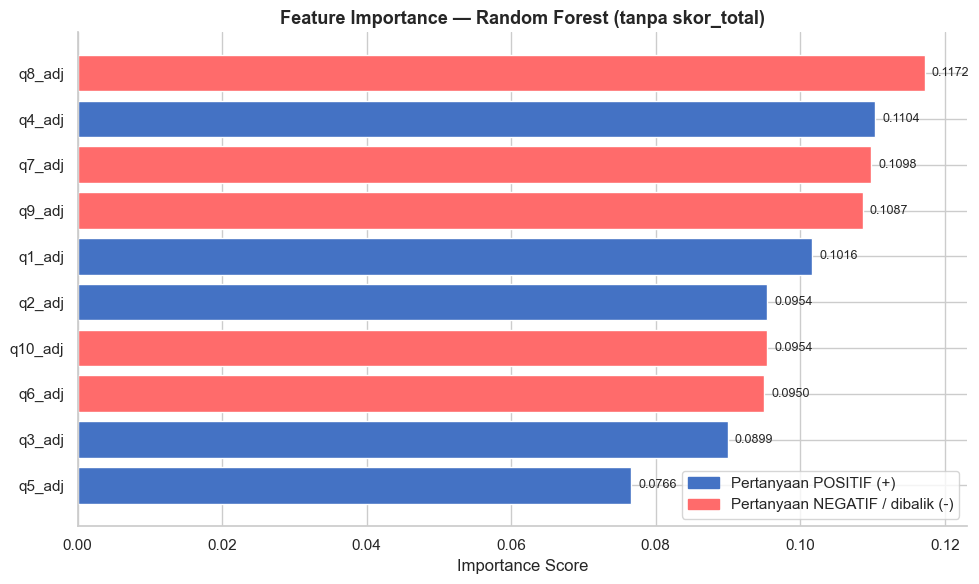

In [20]:
REVERSED_IDX = {5, 6, 7, 8, 9}  # 0-based

importances = rf_best.feature_importances_
feat_df = pd.DataFrame({
    'feature'    : FEATURE_COLS,
    'importance' : importances,
    'tipe'       : ['NEGATIF (dibalik)' if i in REVERSED_IDX else 'POSITIF'
                    for i in range(10)]
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['#FF6B6B' if t == 'NEGATIF (dibalik)' else '#4472C4'
              for t in feat_df['tipe']]
bars = ax.barh(feat_df['feature'], feat_df['importance'],
               color=bar_colors, edgecolor='white')
for bar, val in zip(bars, feat_df['importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_title('Feature Importance — Random Forest (tanpa skor_total)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')

p1 = mpatches.Patch(color='#4472C4',  label='Pertanyaan POSITIF (+)')
p2 = mpatches.Patch(color='#FF6B6B',  label='Pertanyaan NEGATIF / dibalik (-)')
ax.legend(handles=[p1, p2])
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('feat_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Mencetak ranking feature importance
print("Ranking Feature Importance:")
print(f"{'Rank':<5} {'Fitur':<12} {'Importance':>12} {'Tipe'}")
print('-' * 50)
for rank, (_, row) in enumerate(feat_df.sort_values('importance', ascending=False).iterrows(), 1):
    bar = '█' * int(row['importance'] * 300)
    print(f"  {rank:<3}  {row['feature']:<12} {row['importance']:>8.4f}   {bar}")

Ranking Feature Importance:
Rank  Fitur          Importance Tipe
--------------------------------------------------
  1    q8_adj         0.1172   ███████████████████████████████████
  2    q4_adj         0.1104   █████████████████████████████████
  3    q7_adj         0.1098   ████████████████████████████████
  4    q9_adj         0.1087   ████████████████████████████████
  5    q1_adj         0.1016   ██████████████████████████████
  6    q2_adj         0.0954   ████████████████████████████
  7    q10_adj        0.0954   ████████████████████████████
  8    q6_adj         0.0950   ████████████████████████████
  9    q3_adj         0.0899   ██████████████████████████
  10   q5_adj         0.0766   ██████████████████████


In [22]:
MODEL_PATH = 'pss10_rf_model_v2.pkl'

model_artifact = {
    'model'        : rf_best,
    'feature_cols' : FEATURE_COLS,       # ['q1_adj',...,'q10_adj']
    'label_map'    : LABEL_MAP,           # {'RENDAH':0,'SEDANG':1,'TINGGI':2}
    'label_inv'    : LABEL_INV,
    'reversed_idx' : {5,6,7,8,9},        # index pertanyaan yang dibalik
    'best_params'  : grid_search.best_params_,
    'metrics'      : {
        'accuracy_baseline' : round(acc_base, 4),
        'f1_baseline'       : round(f1_base,  4),
        'accuracy_tuned'    : round(acc_best, 4),
        'f1_tuned'          : round(f1_best,  4),
    },
    'versi'        : 'v2 — no skor_total, no SMOTE, class_weight=balanced',
    'n_train'      : len(X_train),
    'n_test'       : len(X_test),
}

joblib.dump(model_artifact, MODEL_PATH)
print(f"✅ Model disimpan: {MODEL_PATH}")
print()
print("Isi artifact:")
for k, v in model_artifact.items():
    if k != 'model':
        print(f"  {k:<22}: {v}")

✅ Model disimpan: pss10_rf_model_v2.pkl

Isi artifact:
  feature_cols          : ['q1_adj', 'q2_adj', 'q3_adj', 'q4_adj', 'q5_adj', 'q6_adj', 'q7_adj', 'q8_adj', 'q9_adj', 'q10_adj']
  label_map             : {'RENDAH': 0, 'SEDANG': 1, 'TINGGI': 2}
  label_inv             : {0: 'RENDAH', 1: 'SEDANG', 2: 'TINGGI'}
  reversed_idx          : {5, 6, 7, 8, 9}
  best_params           : {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
  metrics               : {'accuracy_baseline': 0.87, 'f1_baseline': 0.8557, 'accuracy_tuned': 0.86, 'f1_tuned': 0.8586}
  versi                 : v2 — no skor_total, no SMOTE, class_weight=balanced
  n_train               : 800
  n_test                : 200


In [23]:
# Load model
loaded      = joblib.load(MODEL_PATH)
model_infer = loaded['model']
label_inv_  = loaded['label_inv']
rev_idx     = loaded['reversed_idx']

CONFIDENCE_THRESHOLD = 0.65

def predict_pss10(raw_answers: list) -> dict:
    """
    Input : raw_answers — list 10 integer (0–4), urutan Q1–Q10
    Output: dict lengkap hasil prediksi
    """
    if len(raw_answers) != 10:
        raise ValueError("Harus tepat 10 jawaban (Q1–Q10)")

    # Step 1: Feature engineering (reversal)
    adj = [4 - v if i in rev_idx else v for i, v in enumerate(raw_answers)]

    # Step 2: Hitung skor manual (rule-based, untuk fallback)
    skor = sum(adj)
    if   skor <= 13: label_rule = 'RENDAH'
    elif skor <= 26: label_rule = 'SEDANG'
    else:            label_rule = 'TINGGI'

    # Step 3: Prediksi ML
    X_input   = np.array(adj).reshape(1, -1)
    proba     = model_infer.predict_proba(X_input)[0]
    pred_enc  = model_infer.predict(X_input)[0]
    label_ml  = label_inv_[pred_enc]
    confidence= float(max(proba))

    # Step 4: Tentukan label final
    is_fallback = confidence < CONFIDENCE_THRESHOLD
    label_final = label_rule if is_fallback else label_ml

    # Step 5: Pesan HCAI (bahasa empati)
    pesan_map = {
        'RENDAH': 'Ibu sudah melakukan yang terbaik. Beberapa tips ringan dapat membantu Ibu makin nyaman.',
        'SEDANG': 'Ibu perlu sedikit lebih banyak dukungan — dan itu hal yang wajar dan manusiawi.',
        'TINGGI': 'Ibu tidak harus menghadapi ini sendirian. Ada bantuan yang siap menemani Ibu.'
    }

    return {
        'raw_answers'    : raw_answers,
        'adj_values'     : adj,
        'skor_total'     : skor,
        'label_ml'       : label_ml,
        'label_rule'     : label_rule,
        'label_final'    : label_final,
        'confidence'     : round(confidence, 4),
        'is_fallback'    : is_fallback,
        'prob_rendah'    : round(float(proba[0]), 4),
        'prob_sedang'    : round(float(proba[1]), 4),
        'prob_tinggi'    : round(float(proba[2]), 4),
        'pesan_ui'       : pesan_map[label_final],
    }

print("✅ Fungsi predict_pss10() siap digunakan")

✅ Fungsi predict_pss10() siap digunakan


In [24]:
# ── Simulasi 3 kasus ─────────────────────────────────────────────────────
kasus = {
    'Stres Rendah' : [1, 0, 1, 0, 1, 4, 4, 3, 4, 3],
    'Stres Sedang' : [2, 2, 3, 2, 2, 2, 2, 2, 2, 1],
    'Stres Tinggi' : [4, 4, 4, 3, 4, 0, 0, 1, 0, 0],
}

for nama, jawaban in kasus.items():
    hasil = predict_pss10(jawaban)
    print(f"{'='*52}")
    print(f"  Kasus        : {nama}")
    print(f"  Jawaban Raw  : {jawaban}")
    print(f"  Skor Total   : {hasil['skor_total']}/40")
    print(f"  Label ML     : {hasil['label_ml']}")
    print(f"  Label Rule   : {hasil['label_rule']}")
    print(f"  Label Final  : {hasil['label_final']}")
    print(f"  Confidence   : {hasil['confidence']:.4f}  (fallback: {hasil['is_fallback']})")
    print(f"  Prob         : RENDAH={hasil['prob_rendah']} | SEDANG={hasil['prob_sedang']} | TINGGI={hasil['prob_tinggi']}")
    print(f"  Pesan UI     : {hasil['pesan_ui']}")
print(f"{'='*52}")

  Kasus        : Stres Rendah
  Jawaban Raw  : [1, 0, 1, 0, 1, 4, 4, 3, 4, 3]
  Skor Total   : 5/40
  Label ML     : RENDAH
  Label Rule   : RENDAH
  Label Final  : RENDAH
  Confidence   : 0.9913  (fallback: False)
  Prob         : RENDAH=0.9913 | SEDANG=0.0087 | TINGGI=0.0
  Pesan UI     : Ibu sudah melakukan yang terbaik. Beberapa tips ringan dapat membantu Ibu makin nyaman.
  Kasus        : Stres Sedang
  Jawaban Raw  : [2, 2, 3, 2, 2, 2, 2, 2, 2, 1]
  Skor Total   : 22/40
  Label ML     : SEDANG
  Label Rule   : SEDANG
  Label Final  : SEDANG
  Confidence   : 0.6986  (fallback: False)
  Prob         : RENDAH=0.0153 | SEDANG=0.6986 | TINGGI=0.2861
  Pesan UI     : Ibu perlu sedikit lebih banyak dukungan — dan itu hal yang wajar dan manusiawi.
  Kasus        : Stres Tinggi
  Jawaban Raw  : [4, 4, 4, 3, 4, 0, 0, 1, 0, 0]
  Skor Total   : 38/40
  Label ML     : TINGGI
  Label Rule   : TINGGI
  Label Final  : TINGGI
  Confidence   : 0.9874  (fallback: False)
  Prob         : RENDAH=0.0 

In [25]:
# ── Ringkasan tabel ──────────────────────────────────────────────────────
print(f"\n{'RINGKASAN SIMULASI':^60}")
print(f"{'='*60}")
print(f"{'Kasus':<15} {'Skor':>5} {'Label Final':>12} {'Conf':>8} {'Fallback':>10}")
print('-'*60)
for nama, jawaban in kasus.items():
    h = predict_pss10(jawaban)
    print(f"  {nama:<13} {h['skor_total']:>5} {h['label_final']:>12} "
          f"{h['confidence']:>8.4f} {str(h['is_fallback']):>10}")
print('='*60)


                     RINGKASAN SIMULASI                     
Kasus            Skor  Label Final     Conf   Fallback
------------------------------------------------------------
  Stres Rendah      5       RENDAH   0.9913      False
  Stres Sedang     22       SEDANG   0.6986      False
  Stres Tinggi     38       TINGGI   0.9874      False
